# 13 — BPTT et écrêtage du gradient

La fenêtre fixe est déroulée sur 960 pas :

```text
x1 -> h1 -> h2 -> ... -> h960 -> logit -> loss
      <- gradients propagés en arrière dans le temps <-
```

BPTT multiplie successivement les Jacobiennes récurrentes. Des produits contractants produisent des gradients évanescents ; des produits expansifs produisent des gradients explosifs. Le clipping contrôle les seconds mais ne répare pas les premiers.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import json
import time
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from src.config import *
from src.evaluation import binary_metrics, collect_probabilities, per_subject_metrics, prediction_table, select_threshold
from src.helpers import count_parameters, set_seed
from src.training import pos_weight_from_labels, save_model_artifacts, train_with_early_stopping

set_seed(RANDOM_SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Périphérique :", device, "| CUDA :", torch.cuda.is_available())

Périphérique : cuda | CUDA : True


## 1. Norme globale réutilisable et démonstration sur un lot

In [2]:
from src.models import LSTMClassifier, SimpleRNNClassifier
from src.training import compute_global_gradient_norm

set_seed(RANDOM_SEED)
demo_model = SimpleRNNClassifier(input_size=6, hidden_size=32).to(device)
inputs = torch.randn(4, 960, 6, device=device)
targets = torch.tensor([0., 1., 0., 1.], device=device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(demo_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
optimizer.zero_grad()
logits = demo_model(inputs)
loss = criterion(logits.reshape(-1), targets)
loss.backward()
norm_before = compute_global_gradient_norm(demo_model.parameters())
returned_norm = torch.nn.utils.clip_grad_norm_(demo_model.parameters(), max_norm=1.0)
norm_after = compute_global_gradient_norm(demo_model.parameters())
optimizer.step()
print("avant=", norm_before, "retournée par clip_grad_norm_=", float(returned_norm), "après=", norm_after)
torch.testing.assert_close(torch.tensor(norm_before), returned_norm.detach().cpu())
assert norm_after <= 1.00001

avant= 0.28757521942958686 retournée par clip_grad_norm_= 0.28757521510124207 après= 0.28757521942958686


`clip_grad_norm_` renvoie la norme mesurée **avant** l'écrêtage. Si cette norme ne dépasse pas 1,0, l'opération ne modifie pas les gradients. Elle ne change ni la fonction de perte ni l'architecture.

## 2. Données et comparaison contrôlée

In [3]:
sequence_dir = PROJECT_ROOT / "data" / "processed" / "sequence"
metadata_dir = PROJECT_ROOT / "data" / "processed" / "metadata"
X_train = torch.load(sequence_dir / "X_train.pt", map_location="cpu", weights_only=True).float()
y_train = torch.load(sequence_dir / "y_train.pt", map_location="cpu", weights_only=True).float()
X_validation = torch.load(sequence_dir / "X_validation.pt", map_location="cpu", weights_only=True).float()
y_validation = torch.load(sequence_dir / "y_validation.pt", map_location="cpu", weights_only=True).float()
X_test = torch.load(sequence_dir / "X_test.pt", map_location="cpu", weights_only=True).float()
y_test = torch.load(sequence_dir / "y_test.pt", map_location="cpu", weights_only=True).float()
metadata_train = pd.read_csv(metadata_dir / "windows_train.csv")
metadata_validation = pd.read_csv(metadata_dir / "windows_validation.csv")
metadata_test = pd.read_csv(metadata_dir / "windows_test.csv")

train_subjects = set(metadata_train.subject_id)
val_subjects = set(metadata_validation.subject_id)
test_subjects = set(metadata_test.subject_id)
assert train_subjects.isdisjoint(val_subjects)
assert train_subjects.isdisjoint(test_subjects)
assert val_subjects.isdisjoint(test_subjects)
assert X_train.shape[1:] == X_validation.shape[1:] == X_test.shape[1:] == (960, 6)
assert torch.isfinite(X_train).all() and torch.isfinite(X_validation).all() and torch.isfinite(X_test).all()
print("Train/validation/test :", X_train.shape, X_validation.shape, X_test.shape)

from src.experiments import run_validation_selected_experiment
datasets=(TensorDataset(X_train,y_train),TensorDataset(X_validation,y_validation),TensorDataset(X_test,y_test))

Train/validation/test : torch.Size([1429, 960, 6]) torch.Size([287, 960, 6]) torch.Size([426, 960, 6])


In [4]:
RUN_CLIPPING_EXPERIMENT = False
if RUN_CLIPPING_EXPERIMENT:
    for name, clip in [("without_clipping", None), ("clip_norm_1", 1.0)]:
        run_validation_selected_experiment(
            lambda: SimpleRNNClassifier(input_size=6, hidden_size=32), datasets,
            metadata_validation, metadata_test, PROJECT_ROOT / "artifacts/models/rnn_clipping" / name,
            {"model": "RNN", "architecture": {"hidden_size": 32, "layers": 1}, "seed": RANDOM_SEED,
             "subject_split": SPLIT_SUBJECTS, "input_shape": [960, 6], "normalization_statistics": "train-only sequence scaler"},
            device, compare_weighted_loss=False, gradient_clip=clip,
            record_gradient_norms=True, record_validation_macro_f1=True,
        )
else:
    print("Expérience non exécutée. Les deux réglages réutilisent la même graine, architecture, initialisation, données et optimisation.")

Expérience non exécutée. Les deux réglages réutilisent la même graine, architecture, initialisation, données et optimisation.


## 3. Courbes séparées et interprétations factuelles

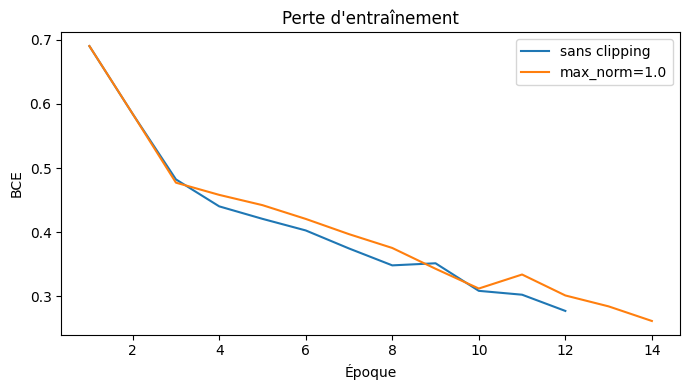

**Interprétation.** Comparer la convergence et rechercher une divergence numérique ; aucune amélioration ne doit être affirmée sans écart observé.

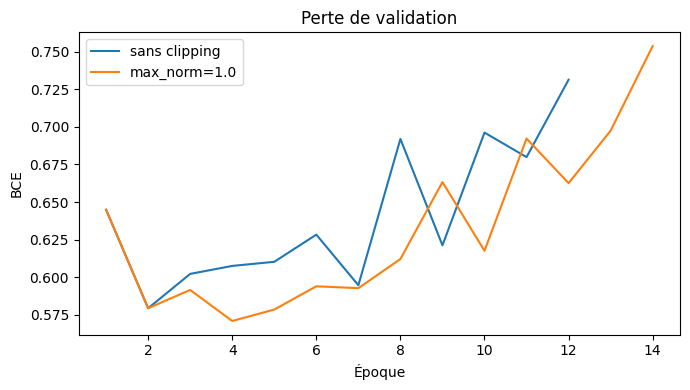

**Interprétation.** Une perte plus stable indique une optimisation plus régulière, pas nécessairement une meilleure généralisation.

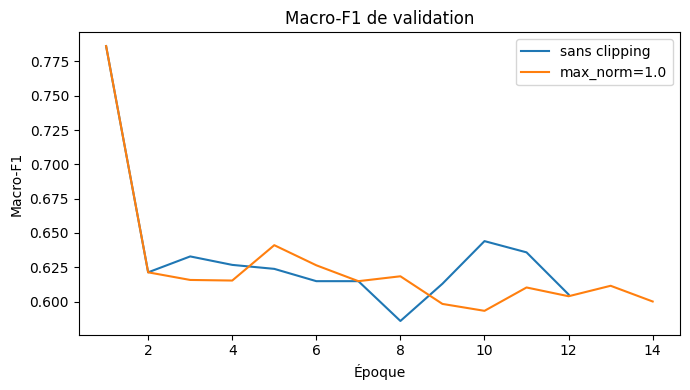

**Interprétation.** Le clipping n'améliore le macro-F1 que si la courbe et le meilleur score de validation le montrent.

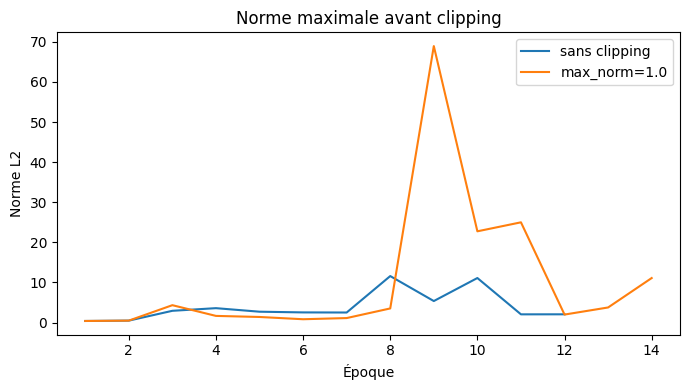

**Interprétation.** Des pics très élevés soutiennent l'hypothèse de gradients instables ; leur absence ne soutient pas cette hypothèse.

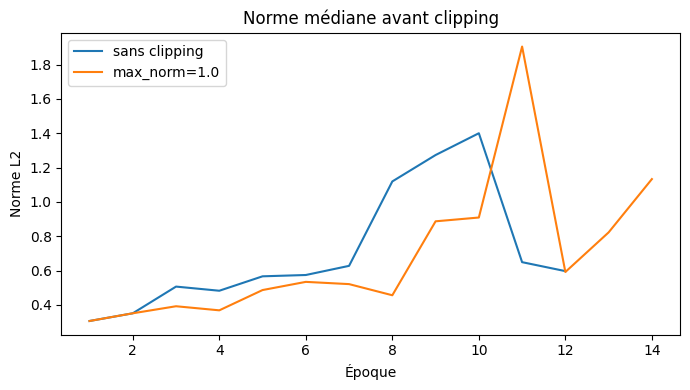

**Interprétation.** La médiane distingue des pics isolés d'une instabilité fréquente.

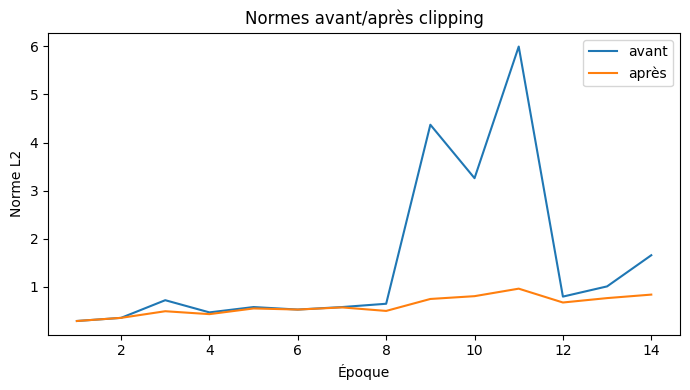

**Interprétation.** Le clipping est activé au moins une fois selon la norme pré-clipping. Il limite les explosions mais ne restaure pas les gradients évanescents.

In [5]:
from IPython.display import Markdown, display
figure_dir = PROJECT_ROOT / "reports/figures/rnn_gradient_clipping"; figure_dir.mkdir(parents=True, exist_ok=True)
paths = {"sans clipping": PROJECT_ROOT / "artifacts/models/rnn_clipping/without_clipping/training_history.csv",
         "max_norm=1.0": PROJECT_ROOT / "artifacts/models/rnn_clipping/clip_norm_1/training_history.csv"}
histories = {name: pd.read_csv(path) for name, path in paths.items() if path.exists()}

def plot_and_interpret(column, title, ylabel, filename, interpretation):
    if not histories:
        print(title, "— artefacts absents."); return
    fig, ax = plt.subplots(figsize=(7, 4))
    for name, frame in histories.items():
        if column in frame: ax.plot(frame.epoch, frame[column], label=name)
    ax.set(title=title, xlabel="Époque", ylabel=ylabel); ax.legend(); fig.tight_layout(); fig.savefig(figure_dir / filename, dpi=150); plt.show()
    display(Markdown("**Interprétation.** " + interpretation))

plot_and_interpret("train_loss", "Perte d'entraînement", "BCE", "training_loss.png", "Comparer la convergence et rechercher une divergence numérique ; aucune amélioration ne doit être affirmée sans écart observé.")
plot_and_interpret("validation_loss", "Perte de validation", "BCE", "validation_loss.png", "Une perte plus stable indique une optimisation plus régulière, pas nécessairement une meilleure généralisation.")
plot_and_interpret("validation_macro_f1", "Macro-F1 de validation", "Macro-F1", "validation_macro_f1.png", "Le clipping n'améliore le macro-F1 que si la courbe et le meilleur score de validation le montrent.")
plot_and_interpret("gradient_pre_max", "Norme maximale avant clipping", "Norme L2", "gradient_pre_max.png", "Des pics très élevés soutiennent l'hypothèse de gradients instables ; leur absence ne soutient pas cette hypothèse.")
plot_and_interpret("gradient_pre_median", "Norme médiane avant clipping", "Norme L2", "gradient_pre_median.png", "La médiane distingue des pics isolés d'une instabilité fréquente.")
if "max_norm=1.0" in histories:
    clipped = histories["max_norm=1.0"]
    fig, ax = plt.subplots(figsize=(7,4)); ax.plot(clipped.epoch, clipped.gradient_pre_mean, label="avant"); ax.plot(clipped.epoch, clipped.gradient_post_mean, label="après")
    ax.set(title="Normes avant/après clipping", xlabel="Époque", ylabel="Norme L2"); ax.legend(); fig.tight_layout(); fig.savefig(figure_dir / "pre_vs_post.png", dpi=150); plt.show()
    activated = bool((clipped.gradient_pre_max > 1.0).any())
    activation_text = "est" if activated else "n'est pas"
    display(Markdown(f"**Interprétation.** Le clipping {activation_text} activé au moins une fois selon la norme pré-clipping. Il limite les explosions mais ne restaure pas les gradients évanescents."))

## 3.1 Synthèse interprétative des courbes

In [6]:
if histories:
    unclipped = histories.get("sans clipping")
    clipped = histories.get("max_norm=1.0")
    unstable = bool(unclipped is not None and (not np.isfinite(unclipped.train_loss).all() or unclipped.gradient_pre_max.max() > 10.0))
    activated = bool(clipped is not None and (clipped.gradient_pre_max > 1.0).any())
    f1_improved = bool(
        unclipped is not None and clipped is not None
        and clipped.validation_macro_f1.max() > unclipped.validation_macro_f1.max()
    )
    display(Markdown(
        f"- Gradients manifestement instables : **{'oui' if unstable else 'non selon ce critère'}**.\n"
        f"- Clipping effectivement activé : **{'oui' if activated else 'non'}**.\n"
        f"- Amélioration du meilleur macro-F1 validation : **{'oui' if f1_improved else 'non observée'}**.\n"
        "- Une baisse de norme soutient une amélioration de stabilité, mais pas automatiquement de généralisation.\n"
        "- Le clipping ne restaure jamais un gradient déjà évanescent."
    ))
else:
    print("Conclusion impossible : exécuter l'expérience contrôlée avant d'interpréter les courbes.")

def load_optional_metrics(directory):
    path = PROJECT_ROOT / "artifacts/models" / directory / "test_metrics.json"
    return json.loads(path.read_text(encoding="utf-8")) if path.exists() else None

rnn_metrics = load_optional_metrics("rnn_fair")
lstm_metrics = load_optional_metrics("lstm_fair")
if rnn_metrics and lstm_metrics:
    rnn_cm = np.asarray(rnn_metrics["confusion_matrix"])
    mostly_non_stress = rnn_cm[:, 0].sum() > rnn_cm[:, 1].sum()
    recall_improved = lstm_metrics["stress_recall"] > rnn_metrics["stress_recall"]
    display(Markdown(
        f"- RNN prédit majoritairement non-stress : **{'oui' if mostly_non_stress else 'non'}**.\n"
        f"- Rappel stress amélioré par le LSTM : **{'oui' if recall_improved else 'non'}**.\n"
        "- Le surcoût paramétrique du LSTM n'est justifié que si ce gain de validation et de rappel est reproductible par sujet."
    ))
else:
    print("Comparaison RNN/LSTM équitable absente : aucune conclusion sur le rappel ou le surcoût paramétrique.")

- Gradients manifestement instables : **oui**.
- Clipping effectivement activé : **oui**.
- Amélioration du meilleur macro-F1 validation : **non observée**.
- Une baisse de norme soutient une amélioration de stabilité, mais pas automatiquement de généralisation.
- Le clipping ne restaure jamais un gradient déjà évanescent.

- RNN prédit majoritairement non-stress : **oui**.
- Rappel stress amélioré par le LSTM : **oui**.
- Le surcoût paramétrique du LSTM n'est justifié que si ce gain de validation et de rappel est reproductible par sujet.

## 4. Comparaison équitable RNN–LSTM

In [7]:
RUN_FAIR_RNN_LSTM = False
if RUN_FAIR_RNN_LSTM:
    fair_results = {}
    for name, factory in {"rnn_fair": lambda: SimpleRNNClassifier(6, 32), "lstm_fair": lambda: LSTMClassifier(6, 32)}.items():
        fair_results[name] = run_validation_selected_experiment(
            factory, datasets, metadata_validation, metadata_test, PROJECT_ROOT / "artifacts/models" / name,
            {"model": name, "architecture": {"hidden_size": 32, "layers": 1, "bidirectional": False}, "seed": RANDOM_SEED,
             "subject_split": SPLIT_SUBJECTS, "input_shape": [960, 6], "normalization_statistics": "train-only sequence scaler"},
            device, compare_weighted_loss=True,
        )

In [8]:
def recurrent_artifact_row(name, directory):
    path = PROJECT_ROOT / "artifacts/models" / directory
    required = ["model_config.json", "validation_metrics.json", "test_metrics.json", "training_summary.json"]
    if not all((path / item).exists() for item in required): return {"model": name, "status": "artefact manquant"}
    data = [json.loads((path / item).read_text(encoding="utf-8")) for item in required]
    cfg, val, test, summary = data
    return {"model": name, "status": "disponible", "parameters": cfg.get("parameter_count"), "validation_macro_f1": val.get("macro_f1"),
            "test_macro_f1": test.get("macro_f1"), "weighted_f1": test.get("weighted_f1"), "stress_precision": test.get("stress_precision"),
            "stress_recall": test.get("stress_recall"), "roc_auc": test.get("roc_auc"), "average_precision": test.get("average_precision"),
            "best_epoch": summary.get("best_epoch"), "training_time": summary.get("training_time_seconds"), "inference_time": test.get("inference_time_seconds"),
            "confusion_matrix": test.get("confusion_matrix")}

fair_table = pd.DataFrame([recurrent_artifact_row("RNN", "rnn_fair"), recurrent_artifact_row("LSTM", "lstm_fair")])
display(fair_table)
if (PROJECT_ROOT / "artifacts/models/rnn_fair/per_subject_metrics.csv").exists(): display(pd.read_csv(PROJECT_ROOT / "artifacts/models/rnn_fair/per_subject_metrics.csv"))
if (PROJECT_ROOT / "artifacts/models/lstm_fair/per_subject_metrics.csv").exists(): display(pd.read_csv(PROJECT_ROOT / "artifacts/models/lstm_fair/per_subject_metrics.csv"))

,model,status,parameters,validation_macro_f1,test_macro_f1,weighted_f1,stress_precision,stress_recall,roc_auc,average_precision,best_epoch,training_time,inference_time,confusion_matrix
0,RNN,disponible,1825,0.750730,0.435170,0.508717,0.226415,0.28125,0.647966,0.427894,10,2.947827,0.013937,"[[175, 123], [92, 36]]"
1,LSTM,disponible,6209,0.797137,0.621518,0.704128,0.615385,0.31250,0.694238,0.573333,4,2.220442,0.012224,"[[273, 25], [88, 40]]"


,subject_id,n_windows,accuracy,macro_f1,weighted_f1,non_stress_precision,non_stress_recall,stress_precision,stress_recall,confusion_matrix,roc_auc,average_precision
0,S11,144,0.715278,0.674442,0.719281,0.810526,0.77,0.530612,0.590909,"[[77, 23], [18, 26]]",0.894091,0.807802
1,S14,144,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,0.000000,"[[0, 100], [44, 0]]",0.000000,0.174728
2,S2,138,0.782609,0.633628,0.731820,0.765625,1.00,1.000000,0.250000,"[[98, 0], [30, 10]]",0.928061,0.835365


,subject_id,n_windows,accuracy,macro_f1,weighted_f1,non_stress_precision,non_stress_recall,stress_precision,stress_recall,confusion_matrix,roc_auc,average_precision
0,S11,144,0.909722,0.896774,0.910992,0.957895,0.91,0.816327,0.909091,"[[91, 9], [4, 40]]",0.985455,0.975955
1,S14,144,0.583333,0.368421,0.511696,0.656250,0.84,0.000000,0.000000,"[[84, 16], [44, 0]]",0.045227,0.176918
2,S2,138,0.710145,0.415254,0.589781,0.710145,1.00,0.000000,0.000000,"[[98, 0], [40, 0]]",0.863010,0.613309


## 5. Discussion attendue

La distribution des prédictions et la matrice de confusion permettent de vérifier si le RNN prédit surtout non-stress. Le rappel stress du LSTM ne constitue une amélioration que s'il dépasse celui du RNN dans l'expérience équitable. Cette amélioration doit ensuite être mise en regard du nombre de paramètres supplémentaire. Avec quinze sujets, ces résultats restent sensibles aux participants de validation et de test.